/var/folders/cc/1drn59n12ql5lmtsd5nw5g900000gn/T/ipykernel_33230/679639736.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')


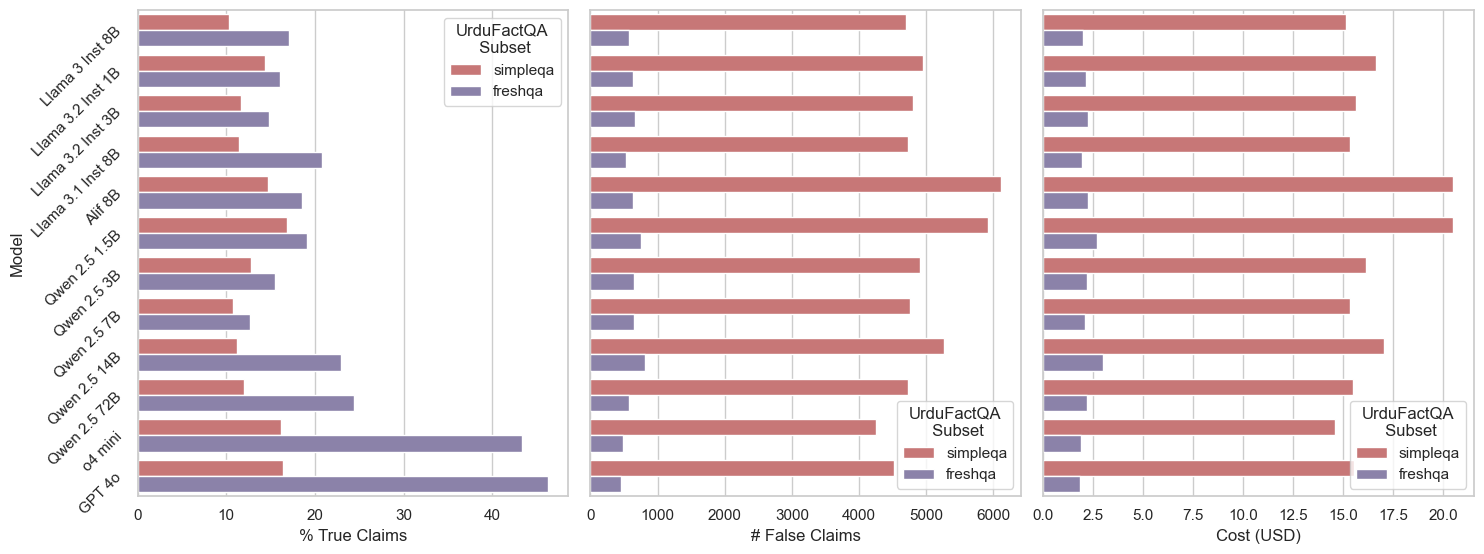

In [135]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your JSON data
with open('evaluate_llm_results.json', 'r') as f:
    data = json.load(f)

# 1. define the desired order
models = [
    "llama-3-8b-instruct",
    "llama-3-2-1b-instruct",
    "llama-3-2-3b-instruct",
    "llama-3-1-8b-instruct",
    "alif-8b",
    "qwen-1-5b",
    "qwen-3b",
    "qwen-7b",
    "qwen-14b",
    "qwen-72b",
    "o4-mini",
    "gpt-4o",
]

# 2. map to display names
model_name_map = {
    "gpt-4o":                   "GPT 4o",
    "o4-mini":                  "o4 mini",
    "alif-8b":                  "Alif 8B",
    "qwen-1-5b":                "Qwen 2.5 1.5B",
    "qwen-3b":                  "Qwen 2.5 3B",
    "qwen-7b":                  "Qwen 2.5 7B",
    "qwen-14b":                 "Qwen 2.5 14B",
    "qwen-72b":                 "Qwen 2.5 72B",
    "llama-3-2-1b-instruct":    "Llama 3.2 Inst 1B",
    "llama-3-2-3b-instruct":    "Llama 3.2 Inst 3B",
    "llama-3-1-8b-instruct":    "Llama 3.1 Inst 8B",
    "llama-3-8b-instruct":      "Llama 3 Inst 8B",
}

# 3. Build a tidy DataFrame with all metrics
rows = []
for m in models:
    disp = model_name_map[m]
    rows.append({
        'Model': disp,
        'Value': data[m]['simpleqa']['percentage_true_claims'],
        'Metric': 'Percentage True Claims',
        'UrduFactQA\n     Subset': 'simpleqa'
    })
    rows.append({
        'Model': disp,
        'Value': data[m]['freshqa']['percentage_true_claims'],
        'Metric': 'Percentage True Claims',
        'UrduFactQA\n     Subset': 'freshqa'
    })
    rows.append({
        'Model': disp,
        'Value': data[m]['simpleqa']['no_of_false_claims'],
        'Metric': 'No of False Claims',
        'UrduFactQA\n     Subset': 'simpleqa'
    })
    rows.append({
        'Model': disp,
        'Value': data[m]['freshqa']['no_of_false_claims'],
        'Metric': 'No of False Claims',
        'UrduFactQA\n     Subset': 'freshqa'
    })
    # if you have total_cost in the JSON similarly:
    rows.append({
        'Model': disp,
        'Value': data[m]['simpleqa']['model_cost'] + data[m]['simpleqa']['serper_cost'],
        'Metric': 'Total Cost',
        'UrduFactQA\n     Subset': 'simpleqa'
    })
    rows.append({
        'Model': disp,
        'Value': data[m]['freshqa']['model_cost'] + data[m]['freshqa']['serper_cost'],
        'Metric': 'Total Cost',
        'UrduFactQA\n     Subset': 'freshqa'
    })

df = pd.DataFrame(rows)

# 4. Set up the figure with 3 columns, shared y-axis
sns.set_theme(style="whitegrid")
palette = {'simpleqa': '#D46A6A', 'freshqa': '#887CAF'}

fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(15, 6),
    sharey=True
)

metrics = ['Percentage True Claims', 'No of False Claims', 'Total Cost']
xlabels = ['% True Claims', '# False Claims', 'Cost (USD)']

for ax, metric, xlabel in zip(axes, metrics, xlabels):
    sns.barplot(
        x='Value',
        y='Model',
        hue='UrduFactQA\n     Subset',
        data=df[df['Metric'] == metric],
        order=[model_name_map[m] for m in models],
        palette=palette,
        ax=ax
    )
    ax.set_xlabel(xlabel)
    if ax is axes[0]:
        ax.set_ylabel('Model')
        # rotate the shared y-ticks once
        ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    else:
        ax.set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("evaluate_llm_results.pdf", bbox_inches='tight')
plt.show()